In [1]:
import sys
sys.path.append('/path/to/scripts')
from inference_tools import InferenceObject
from tqdm import tqdm
from tdc import Oracle
import subprocess
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem

In [2]:
temperature = 1.0
model_path = 'THGLab/Llama-3.1-8B-SmileyLlama-1.1-Mpro'
tokenizer_path = model_path
num_return_sequences = 128
max_new_tokens = 128
io = InferenceObject(model_path, tokenizer_path, num_return_sequences, temperature, max_new_tokens)

PyTorch Using cuda device with 4 GPUs


2025-06-28 11:21:01.357263: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-28 11:21:14.109279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-28 11:21:15.301815: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-28 11:21:15.979471: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-28 11:21:21.232112: I tensorflow/core/platform/cpu_feature_guar

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [3]:
def gen_smiles(io, num_smiles, prompt):
    prompts = [prompt]*-(num_smiles // -128)
    raw_results = []
    strings = io.generate_strings(prompts, generation_params={"temperature":temperature}, disable_tqdm=False)
    for s in strings[0:num_smiles]:
        raw_results += s[1]
    return raw_results

In [4]:
from rdkit.Chem.rdDistGeom import EmbedMolecule
from rdkit.Chem.rdForceFieldHelpers import UFFOptimizeMolecule

def clean_smiles_list(smiles_list, debug=False):

    sanitized_smiles_list = []
    for i, smi in tqdm(enumerate(smiles_list)):
        try:
            # Step 1: Parse SMILES
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                raise ValueError("Invalid SMILES")

            # Step 2: Sanitize
            Chem.SanitizeMol(mol)

            # Step 3: Add hydrogens
            mol_h = Chem.AddHs(mol)

            # Step 4: Generate 3D coordinates
            status = EmbedMolecule(mol_h)
            if status != 0:
                raise ValueError("Embedding failed")

            # Step 5: Optimize geometry
            UFFOptimizeMolecule(mol_h)

            sanitized_smiles_list.append(smi)
        except Exception as e:
            if debug:
                print(e)
            else:
                pass

    return sanitized_smiles_list

In [5]:
system_text = "You love and excel at generating SMILES strings of drug-like molecules"
user_text = 'Output a SMILES string for a drug like molecule with the following properties: High SARS2PRO'
prompt = f"### Instruction:\n{system_text}\n\n### Input:\n{user_text}\n\n### Response:\n"
s2p_smiles = gen_smiles(io, 2560, prompt)
s2p_smiles = clean_smiles_list(s2p_smiles)


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]


 20%|██        | 1/5 [00:30<02:02, 30.60s/it]A


 20%|██        | 1/5 [00:32<02:11, 32.79s/it]

 40%|████      | 2/5 [00:43<01:01, 20.47s/it]


 40%|████      | 2/5 [00:46<01:04, 21.41s/it]

 40%|████      | 2/5 [00:46<01:05, 21.77s/it]

 60%|██████    | 3/5 [00:57<00:34, 17.27s/it]


 60%|██████    | 3/5 [01:00<00:36, 18.20s/it]

 80%|████████  | 4/5 [01:10<00:15, 15.69s/it]


 80%|████████  | 4/5 [01:14<00:16, 16.43s/it]

100%|██████████| 5/5 [01:24<00:00, 16.83s/it]



100%|██████████| 5/5 [01:26<00:00, 17.34s/it]

100%|██████████| 5/5 [01:27<00:00, 17.49s/it]
9it [00:01,  7.66it/s][11:24:21] SMILES Parse Error: unclosed ring for input: 'C1N(C(=O)C2(N1C(c1cc(-c3cc4c(nc(nc4N)-c4cc5c(cccc5)c(c4)F)nc3)cc(c21)F)ccc1c3c([nH]cc3)nc1-2)C)C'
11it [00:01,  9.92it/s][11:24:21] SMILES Parse Error: unclosed ring for input: 'c1(cc2c(nc(nc2Nc2cc(ccc2)C(N2C[C@H](O[C@H](C)C2)C)=O)N)-c2c1cc(cc2)C)C1=CC(C(=C(C1)C)C(=O)N1C

In [6]:
system_text = "You love and excel at generating SMILES strings of drug-like molecules"
user_text = 'Output a SMILES string for a drug like molecule with the following properties: <= 5 H-bond donors, <= 10 H-bond acceptors, <= 500 molecular weight, <= 5 logP, High SARS2PRO'
prompt = f"### Instruction:\n{system_text}\n\n### Input:\n{user_text}\n\n### Response:\n"
ro5_smiles = gen_smiles(io, 2560, prompt)
ro5_smiles = clean_smiles_list(ro5_smiles)

  0%|          | 0/5 [00:00<?, ?it/s]


  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:07<00:31,  7.94s/it]

 20%|██        | 1/5 [00:08<00:34,  8.68s/it]


 20%|██        | 1/5 [00:13<00:54, 13.54s/it]

 40%|████      | 2/5 [00:21<00:30, 10.28s/it]


 40%|████      | 2/5 [00:23<00:36, 12.12s/it]

 60%|██████    | 3/5 [00:29<00:18,  9.22s/it]


 60%|██████    | 3/5 [00:31<00:20, 10.38s/it]

 80%|████████  | 4/5 [00:38<00:08,  8.95s/it]


 80%|████████  | 4/5 [00:40<00:09,  9.70s/it]

100%|██████████| 5/5 [00:46<00:00,  9.38s/it]



100%|██████████| 5/5 [00:54<00:00, 10.94s/it]
2it [00:00, 10.98it/s][11:50:14] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6
64it [00:37,  9.92it/s][11:50:51] SMILES Parse Error: syntax error while parsing: c1cc2c(cc1)nc(nc2N1C[C@H](Oc2cc3c(cc2-f2c4c(nc(c2=O)N)nc(nc4N)N)ccnc3)CC1)C
[11:50:51] SMILES Parse Error: Failed parsing SMILES 'c1cc2c(cc1)nc(nc2N1C[C@H](Oc2cc3c(cc2-f2c4c(nc(c2=O)N)nc(nc4N)N)ccnc3)CC1)C' for input: 'c1cc2c(cc1)

In [7]:
def score_SARS2PRO(smiles_list):
    scratch_scores = '.inference_results'
    smilesfile = scratch_scores + '/smiles.txt'
    scoresfile = scratch_scores + '/scores.txt'
    with open(smilesfile, 'w+') as out:
        for item in smiles_list:
            out.write(item + '\n')
    scoring_python = '/path/to/iminer/python/'
    inp_smiles = ['--input_smiles', str(smilesfile)]
    out_scores = ['--output_csv', str(scoresfile)]
    scoring_program = 'tools/docking_score.py'
    subprocess.run([scoring_python, scoring_program] + inp_smiles + out_scores)

    smiles_scores = []
    with open(scoresfile, 'r') as fil:
        for row in fil:
            try:
                r = row.rstrip().split(',')
                smiles_scores.append((r[0], float(r[1])))
            except:
                print('score not found in row: ' + str(row))
    return smiles_scores

In [11]:
s2p = score_SARS2PRO(s2p_smiles[:2000])

2025-06-28 14:42:29,013 - INFO - Added protein Mpro_7L11 to the project. Current number of proteins: 1
2025-06-28 14:46:50,988 - INFO - Added 2000 ligands to the project. Current number of ligands: 2000


adding gasteiger charges to peptide
All results logged in ._2025_06_28_14_42_22
Querying reward...


2025-06-28 14:46:52,225 - INFO - Start docking 2000 ligands with vina-gpu using 4 cores...
100%|██████████| 2000/2000 [34:29<00:00,  1.03s/it]
2025-06-28 15:21:21,600 - INFO - vina-gpu docking finished
2025-06-28 15:21:21,725 - INFO - Consensus docking completed! Results saved to /path/to/results/1.csv


Reward collection finished
score not found in row: smiles,score



In [12]:
ro5 = score_SARS2PRO(ro5_smiles[:2000])

2025-06-28 15:21:33,175 - INFO - Added protein Mpro_7L11 to the project. Current number of proteins: 1
2025-06-28 15:29:13,485 - INFO - Added 2001 ligands to the project. Current number of ligands: 2000


adding gasteiger charges to peptide


2025-06-28 15:29:15,975 - INFO - Start docking 2000 ligands with vina-gpu using 4 cores...
  0%|          | 0/2000 [00:00<?, ?it/s]

All results logged in ._2025_06_28_15_21_32
Querying reward...
Bad smiles string: N1(C(=O)[C@@H]2[C@@H](C1)C2(c1cc2c(cc1)nc(nc2N)-c1cc(ccc1)C)C)C(=O)N1Cc2c(cccc2)C1. Ignored.


100%|██████████| 2000/2000 [30:00<00:00,  1.11it/s]
2025-06-28 15:59:16,970 - INFO - vina-gpu docking finished
2025-06-28 15:59:17,028 - INFO - Consensus docking completed! Results saved to /path/to/results/1.csv


Reward collection finished
score not found in row: smiles,score



In [21]:
import pickle

with open("inference_mpro/s2p.pkl", 'wb') as f:
    pickle.dump(s2p, f)

with open("inference_mpro/ro5.pkl", 'wb') as f:
    pickle.dump(ro5, f)


In [22]:
with open("inference_mpro/s2p.pkl", 'rb') as f:
    s2p = pickle.load(f)

with open("inference_mpro/ro5.pkl", 'rb') as f:
    ro5 = pickle.load(f)


In [33]:
def check_lipinski(smiles, debug=False):
    """
    Check if a SMILES string satisfies Lipinski's Rule of Five.
    
    Returns True if all rules are satisfied, False otherwise.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)

    if debug:
        print('H-bond donors:    ',hbd)
        print('H-bond acceptors: ',hba)
        print('Molecular weight: ',mw)
        print('LogP:             ',logp)
    
    return (mw <= 500 and 
            logp <= 5 and 
            hbd <= 5 and 
            hba <= 10)

def print_lipinski_followers(smiles_scores, print_scores=True, count=True, sort=True, reverse=True):
    lipinski_followers = []
    for s in smiles_scores:
        if check_lipinski(s[0]):
            lipinski_followers.append(s)
    
    if sort:
        lipinski_followers.sort(key=lambda x: x[1], reverse=reverse)
    
    for s in lipinski_followers:
        if print_scores:
            print(s[0], s[1])
        else:
            print(s[0])
    
    if count:
        print(len(lipinski_followers), "molecules obey Lipinski's rule of 5")

In [27]:
print_lipinski_followers(s2p)

c1(nc2cc(ccc2c(n1)Nc1cc2c(cc1F)nc(nc2N)N)F)Nc1cc2c(cc1F)[nH]nc2 11.7
c1(cc(-c2cc3c(nc(nc3Nc3cc4c(cc3F)OCCO4)N)cc2)cc2c1[nH]nc2)F 11.3
c1c(-c2cc3c(nc(nc3Nc3cc4c(cc3F)OCCO4)N)cc2)cc2c(c1)[nH]nc2NC(C)=O 11.2
c1c2cc(-c3cc4c(nc(nc4Nc4cc5c(cc4F)OCCO5)N)cc3)nc(c2cc(c1)F)N 11.1
c1(-c2cc3c(nc(nc3Nc3cc4c(cc3F)OCCO4)N)cc2)cc2c([nH]nc2)cc1F 11.066666666666668
c1(-c2cc3c(nc(nc3Nc3cc4c(cc3F)OCCO4)N)cc2)cc2c([nH]nc2)cc1F 11.066666666666668
c1(-c2cc3c(nc(nc3Nc3cc4c(cc3F)OCCO4)N)cc2)cc2c([nH]nc2)cc1F 11.066666666666668
c1(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c([nH]nc2)cc1 11.0
N1(c2cc(-c3nc4c(cccc4)c(n3)Nc3cc4c(cc3F)nc(nc4N)N)cc(c2)C)CCOCC1 10.9
c1(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c(ncnc2N)c(c1)F 10.8
c1cc2c(cc1)c(nc(-c1cc3c(cc1)nc(nc3N)N)c2)Nc1cc2c(cc1)nc(nc2N)N 10.8
c1(-c2cc3c(nc(nc3Nc3cc(ccc3)C(N3C[C@H](O[C@H](C)C3)C)=O)N)cc2)cc2c([nH]nc2)cc1 10.799999999999999
c1(-c2cc3c(nc(nc3Nc3cc(ccc3)C(N3C[C@H](O[C@H](C)C3)C)=O)N)cc2)cc2c([nH]nc2)cc1 10.799999999999999
c1(-c2cc3c(cc2)nc(nc3Nc2cc(ccc2)C(

In [28]:
print_lipinski_followers(ro5)

c1c2cc(-c3nc4c(ncnc4Nc4cc5c(cc4F)OCCO5)cc3)cc(c2[nH]n1)F 11.1
c1cc2cc(-c3nc4c(ncnc4Nc4cc5c(cc4F)OCCO5)cc3)ccc2nc1N 11.1
c1cc(-c2cc3c(nc(nc3Nc3cc4c(cc3F)OCCO4)N)cc2)cc2c1[nH]nc2C 11.1
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1cc(-c2cc3c(ncnc3Nc3cc4c(cc3F)OCCO4)cc2)cc2c1[nH]nc2N 11.000000000000002
c1(

In [35]:
check_lipinski('c1(nc2cc(ccc2c(n1)Nc1cc2c(cc1F)nc(nc2N)N)F)Nc1cc2c(cc1F)[nH]nc2',debug=True)

H-bond donors:     5
H-bond acceptors:  9
Molecular weight:  470.4470000000001
LogP:              4.379100000000001


True

In [16]:
import sys
sys.path.append("/path/to/iminer/python/")
from iMiner.rl_generate.evaluators.drug_likeliness import DrugLikeliness
dl = DrugLikeliness()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
import warnings
warnings.filterwarnings('ignore')

def calculate_molecular_properties(smiles_lists, labels=None):
    """
    Calculate molecular properties from multiple SMILES lists
    
    Parameters:
    smiles_lists: list of lists, where each inner list contains SMILES strings
    labels: list of strings for labeling each dataset (optional)
    """
    if not isinstance(smiles_lists[0], list):
        # Handle single list input for backward compatibility
        smiles_lists = [smiles_lists]
    
    if labels is None:
        labels = [f'Dataset {i+1}' for i in range(len(smiles_lists))]
    
    all_properties = []
    
    for idx, smiles_list in enumerate(smiles_lists):
        properties = []
        
        for smiles in smiles_list:
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                # Calculate properties
                hbd = rdMolDescriptors.CalcNumHBD(mol)  # H-bond donors
                hba = rdMolDescriptors.CalcNumHBA(mol)  # H-bond acceptors
                mw = Descriptors.MolWt(mol)  # Molecular weight
                logp = Crippen.MolLogP(mol)  # LogP
                drug_likeness = dl.calc_score(smiles)
                
                properties.append({
                    'SMILES': smiles,
                    'H_bond_donors': hbd,
                    'H_bond_acceptors': hba,
                    'Molecular_weight': mw,
                    'LogP': logp,
                    'Drug Likeness': drug_likeness,
                    'Dataset': labels[idx]
                })
            else: pass
        
        all_properties.extend(properties)
    
    return pd.DataFrame(all_properties)

def create_property_plots(df):
    """
    Create overlapping bar charts and KDE plots for molecular properties from multiple datasets
    """
    # Set up the plotting style
    plt.style.use('default')
    
    # Colorblind-friendly colors: orange, blue, green
    colors = ['#FF8C00', '#1E90FF', '#D3D3D3']  # Dark orange, dodger blue, light gray
    
    # Create figure with subplots
    fig, axes = plt.subplots(3, 2, figsize=(15, 13))
    #fig.suptitle('Molecular Property Distributions', fontsize=16, fontweight='bold')
    
    datasets = df['Dataset'].unique()
    
    # Plot 1: H-bond donors bar chart
    hbd_max = int(df['H_bond_donors'].max())
    x_positions = np.arange(hbd_max + 1)
    bar_width = 0.25  # Width of each bar
    
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        counts = [len(data_subset[data_subset['H_bond_donors'] == j]) for j in range(hbd_max + 1)]
        
        # Offset bars for each dataset
        offset = (i - len(datasets)/2 + 0.5) * bar_width
        axes[0, 0].bar(x_positions + offset, counts, bar_width, 
                       color=colors[i % len(colors)], alpha=0.7, 
                       label=dataset, edgecolor='black', linewidth=0.5)
    
    axes[0, 0].set_xlabel('Number of H-bond Donors', fontsize=18)
    axes[0, 0].set_xticks(x_positions)
    axes[0, 0].tick_params(axis='x', labelsize=14)
    axes[0, 0].set_yticks([])
    axes[0, 0].set_ylabel('Frequency', fontsize=18)
    axes[0, 0].set_title('Distribution of H-bond Donors', fontsize=20, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    axes[0, 0].legend(fontsize=18)
    
    # Plot 2: H-bond acceptors bar chart
    hba_max = int(df['H_bond_acceptors'].max())
    x_positions = np.arange(hba_max + 1)
    
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        counts = [len(data_subset[data_subset['H_bond_acceptors'] == j]) for j in range(hba_max + 1)]
        
        # Offset bars for each dataset
        offset = (i - len(datasets)/2 + 0.5) * bar_width
        axes[0, 1].bar(x_positions + offset, counts, bar_width, 
                       color=colors[i % len(colors)], alpha=0.7, 
                       label=dataset, edgecolor='black', linewidth=0.5)
    
    axes[0, 1].set_xlabel('Number of H-bond Acceptors', fontsize=18)
    axes[0, 1].set_xticks(x_positions)
    axes[0, 1].tick_params(axis='x', labelsize=14)
    axes[0, 1].set_yticks([])
    axes[0, 1].set_ylabel('Frequency', fontsize=18)
    axes[0, 1].set_title('Distribution of H-bond Acceptors', fontsize=20, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    axes[0, 1].legend(fontsize=18)
    
    # Plot 3: Molecular weight KDE
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        sns.kdeplot(data=data_subset, x='Molecular_weight', ax=axes[1, 0], 
                    fill=True, alpha=0.5, color=colors[i % len(colors)], 
                    linewidth=2, label=dataset)
    
    axes[1, 0].set_xlabel('Molecular Weight (Da)', fontsize=18)
    axes[1, 0].tick_params(axis='x', labelsize=14)
    axes[1, 0].set_ylabel('Density', fontsize=18)
    axes[1, 0].set_yticks([])
    axes[1, 0].set_title('Molecular Weight Distribution (KDE)', fontsize=20, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend(fontsize=18)
    
    # Plot 4: LogP KDE
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        sns.kdeplot(data=data_subset, x='LogP', ax=axes[1, 1], 
                    fill=True, alpha=0.5, color=colors[i % len(colors)], 
                    linewidth=2, label=dataset)
    
    axes[1, 1].set_xlabel('LogP', fontsize=18)
    axes[1, 1].tick_params(axis='x', labelsize=14)
    axes[1, 1].set_ylabel('Density', fontsize=18)
    axes[1, 1].set_yticks([])
    axes[1, 1].set_title('LogP Distribution (KDE)', fontsize=20, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend(fontsize=18)


    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        sns.kdeplot(data=data_subset, x='Drug Likeness', ax=axes[2, 0], 
                    fill=True, alpha=0.5, color=colors[i % len(colors)], 
                    linewidth=2, label=dataset, bw_adjust=0.8)
    
    axes[2, 0].set_xlabel('Score', fontsize=18)
    axes[2, 0].tick_params(axis='x', labelsize=14)
    axes[2, 0].set_ylabel('Density', fontsize=18)
    axes[2, 0].set_yticks([])
    axes[2, 0].set_title('Drug-Likeness Score', fontsize=20, fontweight='bold')
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend(fontsize=18)

    
    for i, dataset in enumerate(datasets):
        data_subset = df[df['Dataset'] == dataset]
        sns.kdeplot(data=data_subset, x='Docking Score', ax=axes[2, 1], 
                    fill=True, alpha=0.5, color=colors[i % len(colors)], 
                    linewidth=2, label=dataset, bw_adjust=0.2)
    
    axes[2, 1].set_xlabel('Docking Score (-kcal/mol)', fontsize=18)
    axes[2, 1].tick_params(axis='x', labelsize=14)
    axes[2, 1].set_ylabel('Density', fontsize=18)
    axes[2, 1].set_yticks([])
    axes[2, 1].set_title('Docking Score Distribution (KDE)', fontsize=20, fontweight='bold')
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].legend(fontsize=18)
    
    
    #Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    plt.savefig('prompt_property_comparison.png', dpi=600, bbox_inches='tight')
    plt.show()
    
    return fig

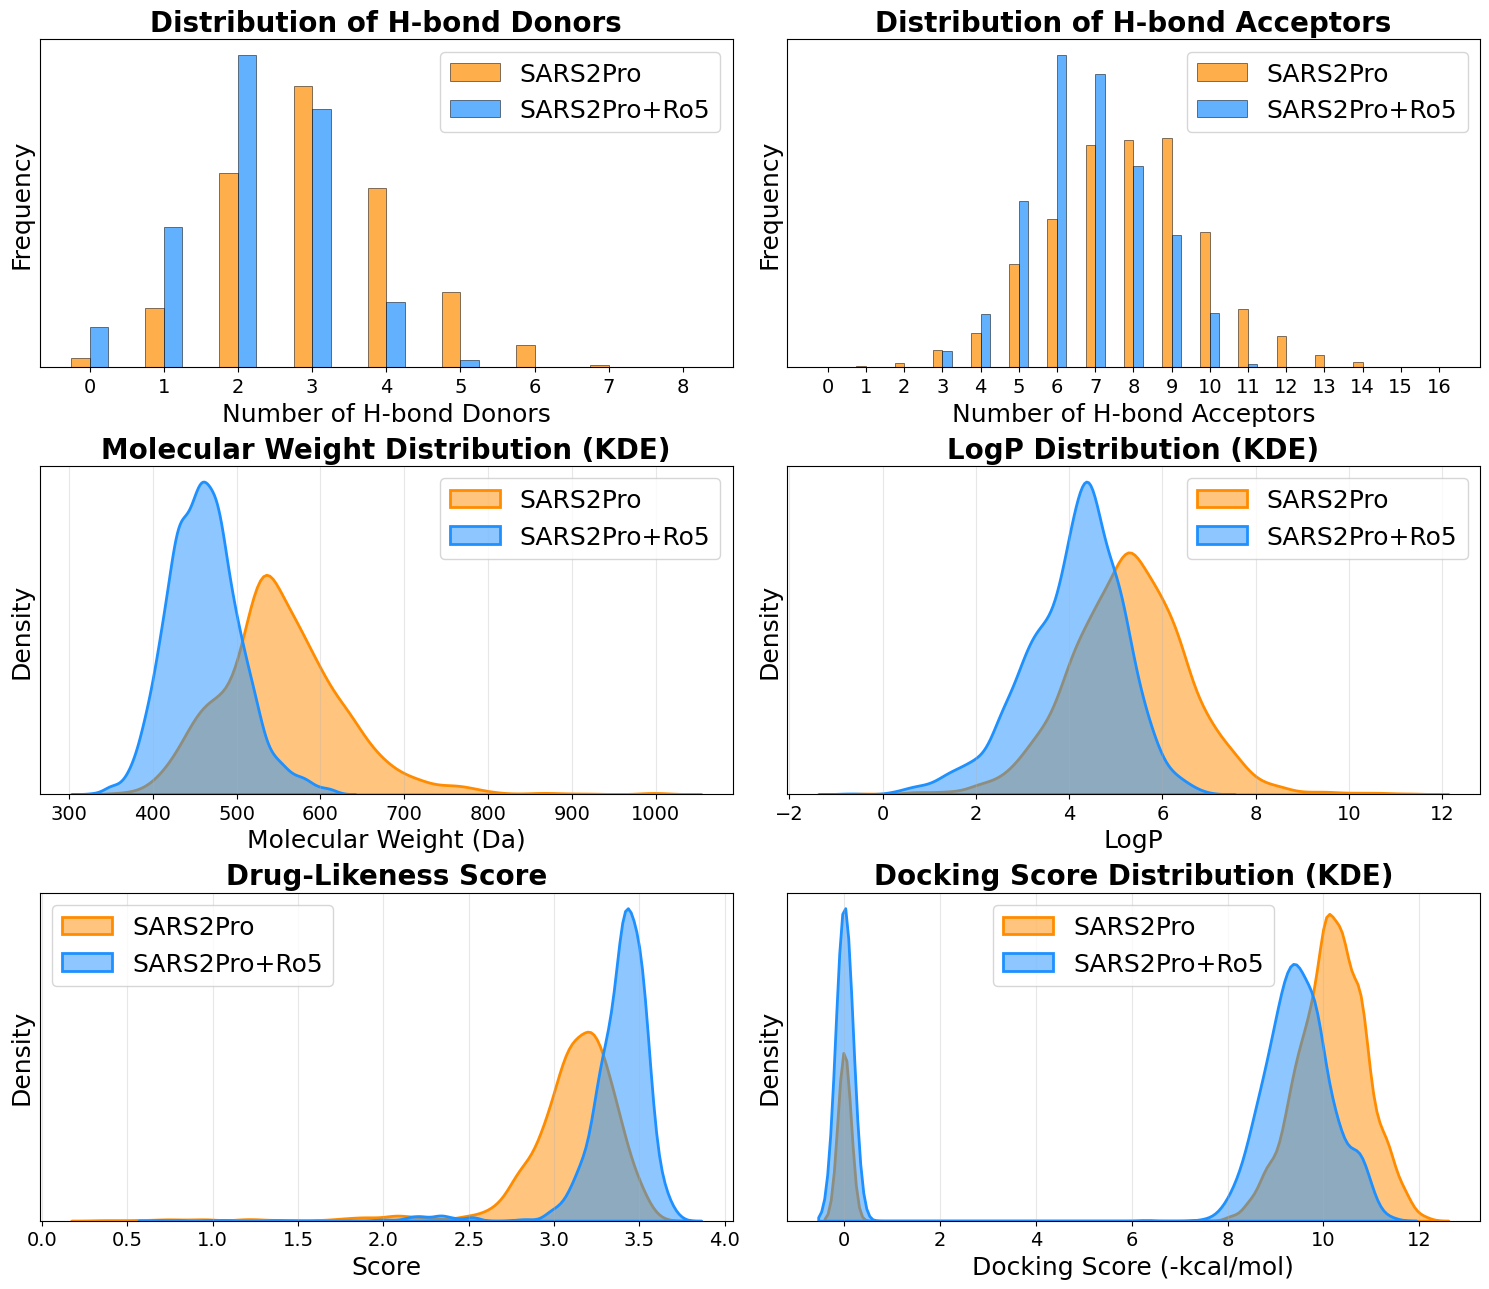

In [18]:
s2p_smiles = [s[0] for s in s2p]
ro5_smiles = [r[0] for r in ro5]

df = calculate_molecular_properties([s2p_smiles, ro5_smiles], labels=['SARS2Pro', 'SARS2Pro+Ro5'])

docking_scores = []
docking_scores += [s[1] for s in s2p if Chem.MolFromSmiles(s[0]) != None and s[0] != ""]
docking_scores += [s[1] for s in ro5 if Chem.MolFromSmiles(s[0]) != None and s[0] != ""]

df['Docking Score'] = docking_scores

# Create plots
fig = create_property_plots(df)
